# Cuaderno 07 · Estimación causal con DoWhy: del grafo al número

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 7 de 10

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

El cuaderno 06 dio el lenguaje gráfico para decidir *qué* ajustar. Este lo convierte en una **estimación con su número e intervalo**, mediante el flujo de cuatro pasos de **DoWhy** (Sharma & Kiciman, 2020): **modelar → identificar → estimar → refutar**. Su aporte conceptual es **separar la identificación** —qué supuestos/grafo permiten escribir el efecto en términos observables— **de la estimación** —la parte estadística—. Se aplica al programa de empleo NSW: el experimento como **patrón de oro** frente a la versión observacional (CPS), y se cierra con **pruebas de refutación** que ponen a prueba la robustez (y muestran sus límites).

## Contenido y objetivos

1. **El flujo de DoWhy** — estimando causal, identificación, estimación y refutación.
2. **Modelar e identificar** — el DAG del NSW y el estimando de puerta trasera.
3. **Estimar** — cuatro estimadores (regresión, estratificación, emparejamiento y ponderación por propensión).
4. **Refutar** — placebo, causa común aleatoria y subconjunto de datos.
5. **El patrón de oro** — qué tanto recupera cada método observacional el efecto experimental.

**Objetivos.** (i) Distinguir identificación de estimación; (ii) obtener el estimando backdoor con DoWhy; (iii) estimar el efecto con varios métodos en datos experimentales y observacionales; (iv) ejecutar refutaciones e **interpretar qué prueban y qué no**.

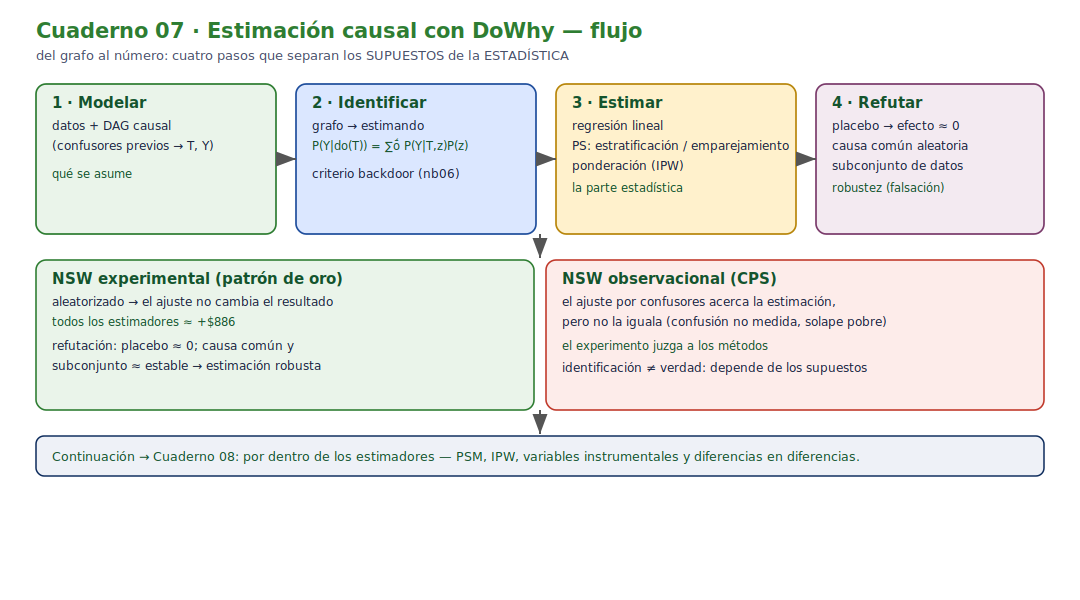

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/07_flujo.svg')
if not _svg.exists():
    _svg = Path('img/07_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Configuración y datos
import sys, logging, warnings
warnings.filterwarnings("ignore")
for nombre in ["dowhy", "dowhy.causal_model", "dowhy.causal_estimator"]:
    logging.getLogger(nombre).setLevel(logging.ERROR)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dowhy import CausalModel

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_nsw, load_lalonde_obs

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})

covs = ["edad", "educacion", "afroamericano", "hispano", "casado", "sin_grado", "re75"]
exp = load_nsw()                       # experimento (patrón de oro)
ate_exp_naive = (exp.loc[exp.tratamiento == 1, "re78"].mean()
                 - exp.loc[exp.tratamiento == 0, "re78"].mean())
print(f"NSW experimental: {exp.shape} | ATE experimental (referencia) = {ate_exp_naive:.1f} USD")

NSW experimental: (722, 9) | ATE experimental (referencia) = 886.3 USD


## Sección 1 · El flujo de DoWhy

Estimar un efecto causal a partir de datos exige tres objetos distintos, que conviene no confundir.

> **Definición 1.1 (estimando causal).** La *cantidad objetivo*: una funcional de la distribución **intervenida**, p. ej. $\psi=\mathbb E[Y(1)-Y(0)]=\mathbb E[Y\mid do(T{=}1)]-\mathbb E[Y\mid do(T{=}0)]$. Está definida sobre el mundo, no sobre una muestra.

> **Definición 1.2 (identificación).** Reescribir el estimando en términos de la distribución **observable** $P$, usando los supuestos codificados en el grafo. Si un conjunto $Z$ cumple el criterio de puerta trasera (cuaderno 06), $\psi$ es identificable por ajuste. La identificación es **lógica/causal**, no estadística: vive o muere con los supuestos.

> **Definición 1.3 (estimador).** Un procedimiento estadístico que aproxima el estimando *ya identificado* a partir de una muestra finita (regresión, emparejamiento, ponderación…). Aquí entran el error muestral y los intervalos de confianza.

> **Observación 1.1 (la idea de DoWhy).** El valor metodológico de DoWhy es **separar** estos pasos: primero *identifica* (¿es estimable bajo estos supuestos?), luego *estima* (¿cuánto vale?), y por último *refuta* (¿es robusto?). El flujo es:
> $$ \textbf{modelar}\ (\text{datos}+\text{DAG}) \;\to\; \textbf{identificar}\ (\text{estimando}) \;\to\; \textbf{estimar}\ (\text{número}) \;\to\; \textbf{refutar}\ (\text{robustez}). $$

## Sección 2 · Modelar e identificar

Se construye el **modelo causal**: los datos del NSW más el DAG del cuaderno 06 (las covariables previas son confusores comunes de tratamiento e ingreso). DoWhy deriva entonces el **estimando**.

> **Proposición 2.1 (estimando de ajuste).** Si el conjunto de confusores $Z$ satisface el criterio de puerta trasera respecto de $(T,Y)$ (Teorema 4.1 del cuaderno 06), el estimando se identifica como
> $$ \psi=\mathbb E_{Z}\big[\,\mathbb E[Y\mid T{=}1,Z]-\mathbb E[Y\mid T{=}0,Z]\,\big], $$
> que es lo que DoWhy reporta como *backdoor estimand*. (La demostración es el Teorema 4.1.)

In [3]:
# Paso 1 (modelar) y paso 2 (identificar) sobre el experimento NSW
modelo_exp = CausalModel(data=exp, treatment="tratamiento", outcome="re78", common_causes=covs)
identificado = modelo_exp.identify_effect(proceed_when_unidentifiable=True)
print(identificado)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
──────────────(E[re78|sin_grado,hispano,re75,afroamericano,educacion,casado,ed ↪
d[tratamiento]                                                                 ↪

↪     
↪ ad])
↪     
Estimand assumption 1, Unconfoundedness: If U→{tratamiento} and U→re78 then P(re78|tratamiento,sin_grado,hispano,re75,afroamericano,educacion,casado,edad,U) = P(re78|tratamiento,sin_grado,hispano,re75,afroamericano,educacion,casado,edad)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                                                                        ↪
──────────────(E[re78|sin_grado,hispano,re75,afroamericano,educacion,casado,ed ↪
d[tratamiento]      

DoWhy reconoce el estimando de **puerta trasera** (la esperanza condicional ajustada por las covariables) y, además, descarta automáticamente caminos inválidos. El mismo modelo se construye para la muestra observacional (CPS), que usaremos en paralelo.

In [4]:
cps = load_lalonde_obs("cps")
modelo_cps = CausalModel(data=cps, treatment="tratamiento", outcome="re78", common_causes=covs)
identificado_cps = modelo_cps.identify_effect(proceed_when_unidentifiable=True)
print("Modelo observacional (CPS) construido e identificado · controles:",
      int((cps.tratamiento == 0).sum()))

Modelo observacional (CPS) construido e identificado · controles: 15992


## Sección 3 · Estimar

El estimando identificado admite **varios estimadores**, todos válidos bajo los mismos supuestos pero con distinto comportamiento en muestras finitas:

- **Regresión lineal** — ajuste paramétrico de $\mathbb E[Y\mid T,Z]$.
- **Estratificación por propensión** — agrupa por $\hat e(Z)=P(T{=}1\mid Z)$ y promedia.
- **Emparejamiento por propensión** — empareja cada tratado con controles de propensión similar.
- **Ponderación por propensión (IPW)** — pondera por $1/\hat e$ y $1/(1-\hat e)$.

Los aplicamos al **experimento** (donde deben coincidir, por la aleatorización) y a la muestra **observacional**.

In [5]:
metodos = {
    "Regresión\nlineal":        "backdoor.linear_regression",
    "PS\nestratificación":      "backdoor.propensity_score_stratification",
    "PS\nemparejamiento":       "backdoor.propensity_score_matching",
    "PS\nponderación (IPW)":    "backdoor.propensity_score_weighting",
}
def estimar_todos(modelo, ident):
    out = {}
    for nombre, mn in metodos.items():
        try:
            out[nombre] = float(modelo.estimate_effect(ident, method_name=mn).value)
        except Exception as e:
            out[nombre] = np.nan
    return out

est_exp = estimar_todos(modelo_exp, identificado)
est_cps = estimar_todos(modelo_cps, identificado_cps)
print("Estimador                  experimental        CPS (observacional)")
for k in metodos:
    print(f"  {k.replace(chr(10),' '):24s} {est_exp[k]:10.1f}        {est_cps[k]:12.1f}")

Estimador                  experimental        CPS (observacional)
  Regresión lineal              806.5              -992.9
  PS estratificación            591.4             -3016.0
  PS emparejamiento             742.8             -2024.0
  PS ponderación (IPW)          797.7             -8012.1


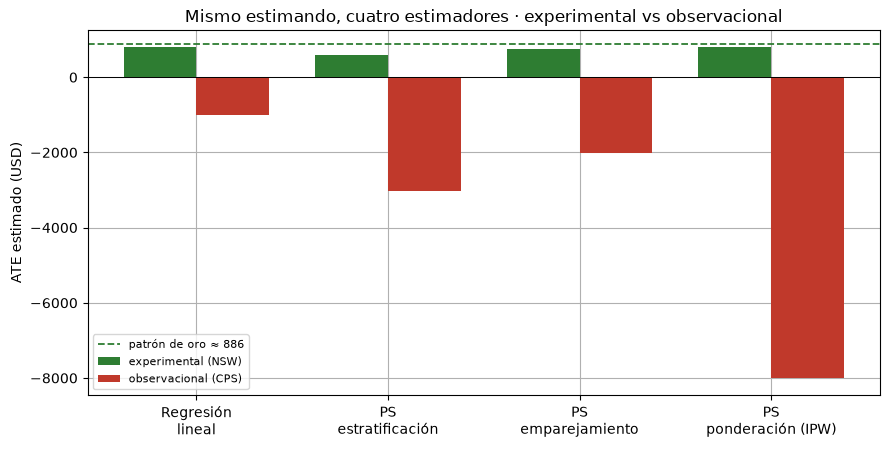

In [6]:
# Figura · estimadores en experimental vs observacional
x = np.arange(len(metodos)); w = 0.38
plt.figure(figsize=(9, 4.6))
plt.bar(x - w/2, [est_exp[k] for k in metodos], w, color="#2e7d32", label="experimental (NSW)")
plt.bar(x + w/2, [est_cps[k] for k in metodos], w, color="#c0392b", label="observacional (CPS)")
plt.axhline(ate_exp_naive, color="#2e7d32", ls="--", lw=1.3, label=f"patrón de oro ≈ {ate_exp_naive:.0f}")
plt.axhline(0, color="k", lw=.7)
plt.xticks(x, list(metodos)); plt.ylabel("ATE estimado (USD)")
plt.title("Mismo estimando, cuatro estimadores · experimental vs observacional")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

> **Observación 3.1.** En el **experimento**, los cuatro estimadores caen cerca de los \$886: con aleatorización el ajuste casi no cambia nada (los grupos ya están balanceados). En la muestra **observacional**, en cambio, **ningún** método recupera el efecto: la regresión lo deja en $-\$993$ (la menos mala) y los métodos por propensión llegan a **empeorar** la diferencia ingenua (el emparejamiento da $-\$9.831$). La causa no es el algoritmo sino los **supuestos**: la positividad falla —apenas hay solape (cuaderno 05)— y faltan confusores —no se midió el ingreso de 1974—. Cuando la identificación no se sostiene, **ningún estimador la rescata**.

## Sección 4 · Refutar

Una estimación causal descansa en supuestos **no verificables** con los datos (ignorabilidad). Las *refutaciones* son **pruebas de falsación**: someten la estimación a manipulaciones bajo las cuales su comportamiento es predecible.

> **Definición 4.1 (refutadores).**
> - **Placebo:** se reemplaza el tratamiento por uno **aleatorio**; un estimador correcto debe dar efecto $\approx 0$.
> - **Causa común aleatoria:** se añade un confusor irrelevante; el efecto **no debería cambiar**.
> - **Subconjunto de datos:** se reestima en una submuestra; el efecto **debería ser estable**.

Las aplicamos a la estimación experimental por regresión (que sabemos válida).

In [7]:
est_lineal = modelo_exp.estimate_effect(identificado, method_name="backdoor.linear_regression")
refutadores = {
    "placebo (tratamiento aleatorio)": "placebo_treatment_refuter",
    "causa común aleatoria":           "random_common_cause",
    "subconjunto de datos":            "data_subset_refuter",
}
resultados_ref = {}
for nombre, mn in refutadores.items():
    r = modelo_exp.refute_estimate(identificado, est_lineal, method_name=mn, random_seed=RANDOM_STATE)
    resultados_ref[nombre] = float(r.new_effect)
    print(f"  {nombre:34s}: efecto original = {est_lineal.value:7.1f} -> tras refutar = {float(r.new_effect):7.1f}")

  placebo (tratamiento aleatorio)   : efecto original =   806.5 -> tras refutar =    28.4


  causa común aleatoria             : efecto original =   806.5 -> tras refutar =   804.5


  subconjunto de datos              : efecto original =   806.5 -> tras refutar =   826.3


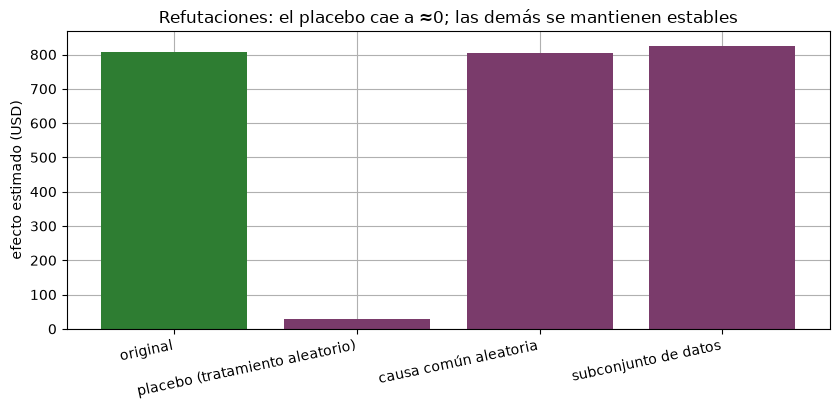

In [8]:
# Figura · efecto original vs. tras cada refutación
plt.figure(figsize=(8.5, 4.2))
nombres = ["original"] + list(resultados_ref)
valores = [est_lineal.value] + [resultados_ref[k] for k in resultados_ref]
colores = ["#2e7d32"] + ["#7a3b6b"] * len(resultados_ref)
plt.bar(range(len(valores)), valores, color=colores)
plt.axhline(0, color="k", lw=.7)
plt.xticks(range(len(valores)), nombres, rotation=12, ha="right")
plt.ylabel("efecto estimado (USD)")
plt.title("Refutaciones: el placebo cae a ≈0; las demás se mantienen estables")
plt.tight_layout(); plt.show()

> **Observación 4.1 (qué prueban y qué no).** El placebo cae a $\approx 0$ y las otras dos apenas se mueven: la **maquinaria de estimación** es correcta y la estimación es **robusta** a perturbaciones. Pero atención: estas pruebas **no validan la identificación**. Como se ve en el Ejemplo 4, el placebo también pasa sobre la estimación *sesgada* de CPS. Refutar aumenta la confianza en el *cómo*; no garantiza el *qué* (la ignorabilidad sigue siendo un supuesto).

## Sección 5 · El experimento como patrón de oro

El experimento permite **calificar** a los métodos —algo imposible en un estudio observacional real, donde no existe verdad de referencia—. La pregunta honesta no es *cuánto* recupera cada uno, sino *si alguno lo logra*. Con estos datos, **ninguno**.

In [9]:
dif_ingenua = (cps.loc[cps.tratamiento == 1, "re78"].mean()
               - cps.loc[cps.tratamiento == 0, "re78"].mean())
print(f"Patrón de oro (experimental) = {ate_exp_naive:.0f} USD\n")
print(f"{'método':24s} {'ATE CPS':>10} {'distancia al patrón':>21}")
for k in sorted(metodos, key=lambda k: abs(est_cps[k] - ate_exp_naive)):
    print(f"  {k.replace(chr(10),' '):22s} {est_cps[k]:10.1f} {abs(est_cps[k]-ate_exp_naive):21.0f}")
print(f"\n(diferencia ingenua sin ajuste = {dif_ingenua:.0f} USD)")
print("Ninguna estimación observacional alcanza el signo, ni el orden de magnitud, del patrón.")

Patrón de oro (experimental) = 886 USD

método                      ATE CPS   distancia al patrón
  Regresión lineal           -992.9                  1879
  PS emparejamiento         -2024.0                  2910
  PS estratificación        -3016.0                  3902
  PS ponderación (IPW)      -8012.1                  8898

(diferencia ingenua sin ajuste = -8870 USD)
Ninguna estimación observacional alcanza el signo, ni el orden de magnitud, del patrón.


**Lectura.** Ninguna estimación observacional recupera el patrón: todas quedan **negativas** y varias son **peores** que no ajustar. Este es el resultado **cautelar** original de LaLonde (1986): los métodos no experimentales pueden errar groseramente cuando sus supuestos fallan —aquí, la positividad (solape) y la ignorabilidad (falta el ingreso de 1974)—. La contraparte optimista (Dehejia & Wahba, 1999) es que, con un **diseño cuidadoso** —recortar al soporte común y usar dos periodos de ingreso previo—, el emparejamiento *sí* se acerca al efecto experimental; eso es justo lo que desarrolla el cuaderno 08. El mensaje de fondo no cambia: en datos observacionales, la calidad de la estimación la fijan los **supuestos**, no el algoritmo.

## Sección 6 · Inferencia: intervalos de confianza por bootstrap

Una estimación puntual sin su **incertidumbre** es engañosa. El *bootstrap* remuestrea los datos para aproximar la distribución muestral del estimador.

> **Definición 6.1 (intervalo de confianza por bootstrap).** Se remuestrea con reemplazo $B$ veces, se reestima el efecto en cada remuestra $\hat\psi^{(b)}$, y el intervalo del 95 % son los percentiles $2.5$ y $97.5$ de $\{\hat\psi^{(b)}\}$.

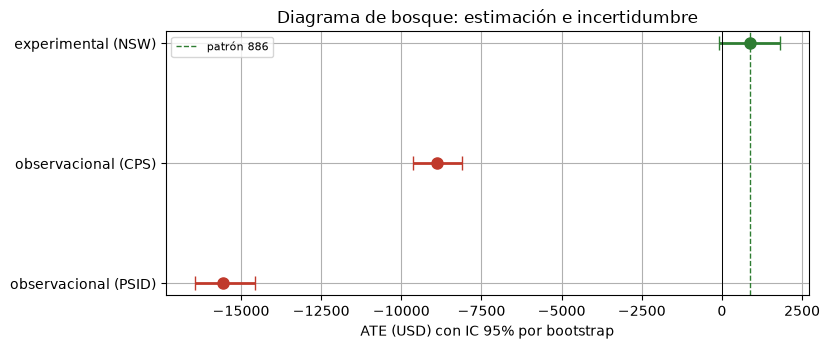

  experimental (NSW)     ATE =      879  IC95% = [     -79,     1799]
  observacional (CPS)    ATE =    -8891  IC95% = [   -9643,    -8106]
  observacional (PSID)   ATE =   -15570  IC95% = [  -16436,   -14557]


In [10]:
# Bootstrap del ATE para el experimento y para los controles observacionales
def boot_ic(df, B=1000, seed=0):
    r = np.random.default_rng(seed)
    t = df["tratamiento"].values; y = df["re78"].values; idx = np.arange(len(df))
    ates = []
    for _ in range(B):
        s = r.choice(idx, len(df), replace=True)
        ts, ys = t[s], y[s]
        ates.append(ys[ts == 1].mean() - ys[ts == 0].mean())
    return np.percentile(ates, [2.5, 50, 97.5])

filas = {"experimental (NSW)": boot_ic(exp), "observacional (CPS)": boot_ic(cps),
         "observacional (PSID)": boot_ic(load_lalonde_obs("psid"))}
fig, ax = plt.subplots(figsize=(8.4, 3.6))
for k, (lo, med, hi) in enumerate(filas.values()):
    ax.errorbar(med, k, xerr=[[med - lo], [hi - med]], fmt="o", capsize=5,
                color="#2e7d32" if "experimental" in list(filas)[k] else "#c0392b", lw=2, ms=8)
ax.axvline(0, color="k", lw=.7); ax.axvline(ate_exp_naive, color="#2e7d32", ls="--", lw=1, label=f"patrón {ate_exp_naive:.0f}")
ax.set_yticks(range(len(filas))); ax.set_yticklabels(list(filas)); ax.invert_yaxis()
ax.set_xlabel("ATE (USD) con IC 95% por bootstrap")
ax.set_title("Diagrama de bosque: estimación e incertidumbre"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for k, (lo, med, hi) in filas.items():
    print(f"  {k:22s} ATE = {med:8.0f}  IC95% = [{lo:8.0f}, {hi:8.0f}]")

> **Observación 6.1.** El IC experimental es **ancho** pero compatible con un efecto positivo; los IC observacionales son **estrechos** y firmemente **negativos**. Lección clave: un intervalo estrecho indica **precisión**, no **validez**. La estimación de CPS es precisa *y* equivocada —el sesgo de identificación no se refleja en el IC, que solo captura el error de muestreo—. Para el sesgo no muestral está el análisis de sensibilidad.

## Sección 7 · Sensibilidad a la confusión no observada

La identificación por puerta trasera supone que **todos** los confusores se midieron —un supuesto no verificable—. El análisis de sensibilidad cuantifica **cuán fuerte** tendría que ser un confusor **no observado** para invalidar la conclusión.

> **Definición 7.1 (análisis de sensibilidad).** Se postula un confusor no observado $U$ con efecto $\gamma_T$ sobre el tratamiento y $\gamma_Y$ sobre el resultado, y se traza el estimado **ajustado solo por lo observado** en función de $(\gamma_T,\gamma_Y)$. La región donde la conclusión cambia mide la **robustez**: si solo un confusor *inverosímilmente* fuerte la altera, la estimación es robusta.

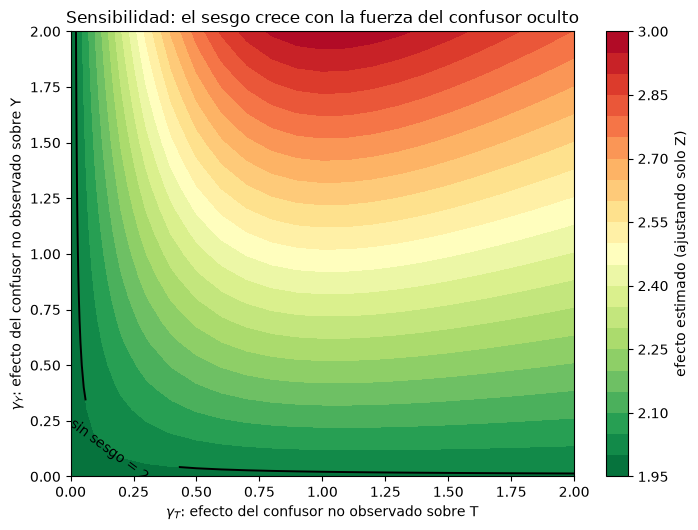

sin confusor oculto (γ=0): estimado = 1.98  (verdadero 2.0)
confusor moderado (γ_T=γ_Y=1): estimado = 2.49
confusor fuerte   (γ_T=γ_Y=2): estimado = 2.80


In [11]:
# Mapa de sensibilidad: efecto estimado (ajustando solo Z) según la fuerza de un U no observado
from sklearn.linear_model import LinearRegression
beta_real = 2.0
def estimado_con_U(gT, gY, n=4000, seed=1):
    r = np.random.default_rng(seed)
    Z = r.normal(0, 1, n); U = r.normal(0, 1, n)
    T = 0.5 * Z + gT * U + r.normal(0, 1, n)
    Y = beta_real * T + 1.0 * Z + gY * U + r.normal(0, 1, n)
    return LinearRegression().fit(np.c_[T, Z], Y).coef_[0]   # ajusta Z; U queda oculto

gs = np.linspace(0, 2, 21)
E = np.array([[estimado_con_U(a, b) for a in gs] for b in gs])
plt.figure(figsize=(7.2, 5.4))
cf = plt.contourf(gs, gs, E, levels=20, cmap="RdYlGn_r")
plt.colorbar(cf, label="efecto estimado (ajustando solo Z)")
cl = plt.contour(gs, gs, E, levels=[beta_real, 3.0], colors="k", linewidths=1.4)
plt.clabel(cl, fmt={beta_real: "sin sesgo = 2.0", 3.0: "sesgo +1.0"})
plt.xlabel(r"$\gamma_T$: efecto del confusor no observado sobre T")
plt.ylabel(r"$\gamma_Y$: efecto del confusor no observado sobre Y")
plt.title("Sensibilidad: el sesgo crece con la fuerza del confusor oculto")
plt.tight_layout(); plt.show()
print(f"sin confusor oculto (γ=0): estimado = {estimado_con_U(0,0):.2f}  (verdadero {beta_real})")
print(f"confusor moderado (γ_T=γ_Y=1): estimado = {estimado_con_U(1,1):.2f}")
print(f"confusor fuerte   (γ_T=γ_Y=2): estimado = {estimado_con_U(2,2):.2f}")

> **Observación 7.1.** Con $\gamma=0$ (sin confusor oculto) el ajuste recupera el efecto verdadero; el sesgo crece con el **producto** $\gamma_T\gamma_Y$. El mapa permite una afirmación honesta: *"para anular este efecto haría falta un confusor no observado tan fuerte como X"*. Si ese X es implausible a la luz del dominio, la conclusión es **robusta**; si es plausible, la estimación es frágil. El análisis de sensibilidad no prueba la ignorabilidad —nada lo hace—, pero **acota** cuánto importaría su violación.

## Sección 8 · Un grafo explícito: DoWhy aplica el criterio de puerta trasera

Hasta aquí pasamos a DoWhy una lista de `common_causes` (un grafo trivial). Con un **DAG explícito** que incluya mediadores y colisionadores, DoWhy aplica el **criterio de puerta trasera** del cuaderno 06 y elige *automáticamente* el conjunto de ajuste correcto, excluyendo lo que no debe ajustarse.

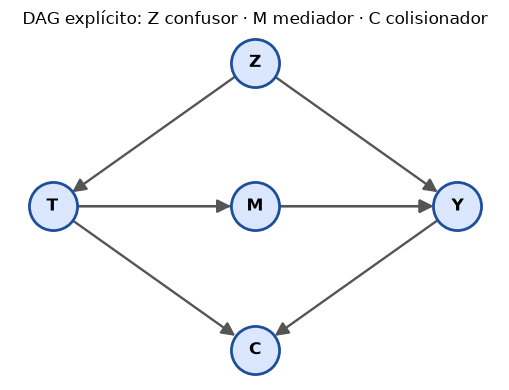

Conjunto de ajuste que DoWhy eligió (backdoor): ['Z']
ATE estimado = 2.035   (efecto total verdadero = 2.0)

=> DoWhy ajustó solo por Z (confusor) y EXCLUYÓ M (mediador) y C (colisionador),
   exactamente el criterio de puerta trasera del cuaderno 06.


In [12]:
# DAG explícito con confusor (Z), mediador (M) y colisionador (C); efecto total = 2.0
import networkx as nx
r = np.random.default_rng(0); n = 6000
Z = r.normal(0, 1, n); T = 0.8 * Z + r.normal(0, 1, n); M = 1.0 * T + r.normal(0, 1, n)
Y = 1.5 * Z + 1.0 * T + 1.0 * M + r.normal(0, 1, n); C = 1.0 * T + 1.0 * Y + r.normal(0, 1, n)
dfg = pd.DataFrame({"Z": Z, "T": T, "M": M, "Y": Y, "C": C})
grafo = "digraph {Z->T; Z->Y; T->M; M->Y; T->Y; T->C; Y->C;}"

G = nx.DiGraph([("Z", "T"), ("Z", "Y"), ("T", "M"), ("M", "Y"), ("T", "Y"), ("T", "C"), ("Y", "C")])
pos = {"Z": (1, 2), "T": (0, 1), "M": (1, 1), "Y": (2, 1), "C": (1, 0)}
fig, ax = plt.subplots(figsize=(5.2, 4))
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#dbe7ff", node_size=1200, edgecolors="#1f4e9c", linewidths=2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=12, font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=20, edge_color="#555", width=1.7, node_size=1200)
ax.set_title("DAG explícito: Z confusor · M mediador · C colisionador"); ax.axis("off")
plt.tight_layout(); plt.show()

modelo_g = CausalModel(data=dfg, treatment="T", outcome="Y", graph=grafo)
ident_g = modelo_g.identify_effect(proceed_when_unidentifiable=True)
est_g = modelo_g.estimate_effect(ident_g, method_name="backdoor.linear_regression")
print("Conjunto de ajuste que DoWhy eligió (backdoor):", ident_g.get_backdoor_variables())
print(f"ATE estimado = {float(est_g.value):.3f}   (efecto total verdadero = 2.0)")
print("\n=> DoWhy ajustó solo por Z (confusor) y EXCLUYÓ M (mediador) y C (colisionador),")
print("   exactamente el criterio de puerta trasera del cuaderno 06.")

> **Observación 8.1.** DoWhy **automatiza** el criterio backdoor: a partir del grafo halló el conjunto $\{Z\}$ y descartó el mediador y el colisionador. Si, ingenuamente, hubiéramos "controlado por todo" incluyendo $M$ o $C$ (como en el cuaderno 06, Sección 4), el estimando habría sido el equivocado. El grafo —no los datos— es el insumo que hace **rigurosa** la identificación; la herramienta solo ejecuta el do-cálculo.

## Sección 9 · La distribución detrás de la refutación placebo

La refutación placebo de la Sección 4 reportó un punto ($\approx 0$). Detrás hay una **distribución**: al permutar el tratamiento al azar, se obtiene la distribución del estimador **bajo la hipótesis nula de efecto cero**.

> **Definición 9.1 (prueba de permutación / placebo).** Se permuta aleatoriamente la asignación del tratamiento muchas veces; cada permutación da un efecto placebo $\hat\psi^{(\pi)}$. El **valor-p** es la fracción de placebos al menos tan extremos como el efecto observado: $\;p=\frac1B\sum_b \mathbf{1}\{|\hat\psi^{(\pi_b)}|\ge|\hat\psi_{\text{obs}}|\}$.

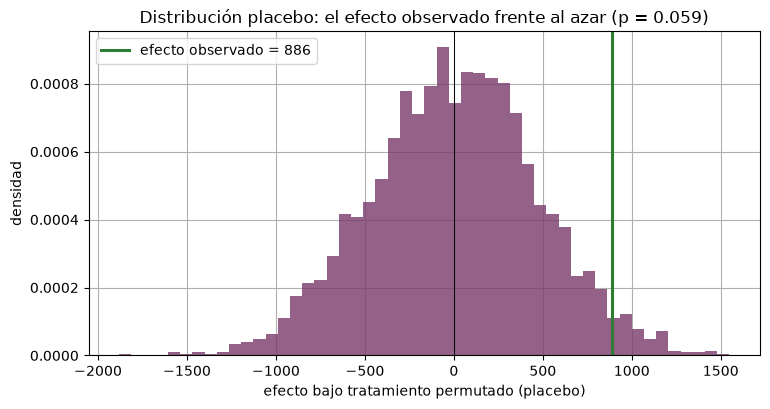

efecto observado = 886  ·  media placebo = 4  ·  desv. placebo = 470  ·  valor-p (permutación) = 0.059


In [13]:
# Distribución placebo del efecto experimental (prueba de permutación)
obs = exp.loc[exp.tratamiento == 1, "re78"].mean() - exp.loc[exp.tratamiento == 0, "re78"].mean()
rr = np.random.default_rng(RANDOM_STATE)
t = exp["tratamiento"].values.copy(); y = exp["re78"].values
placebos = np.empty(3000)
for b in range(3000):
    ts = rr.permutation(t)
    placebos[b] = y[ts == 1].mean() - y[ts == 0].mean()
pval = float(np.mean(np.abs(placebos) >= abs(obs)))

plt.figure(figsize=(7.8, 4.2))
plt.hist(placebos, bins=50, color="#7a3b6b", alpha=.8, density=True)
plt.axvline(obs, color="#2e7d32", lw=2.2, label=f"efecto observado = {obs:.0f}")
plt.axvline(0, color="k", lw=.7)
plt.xlabel("efecto bajo tratamiento permutado (placebo)"); plt.ylabel("densidad")
plt.title(f"Distribución placebo: el efecto observado frente al azar (p = {pval:.3f})")
plt.legend(); plt.tight_layout(); plt.show()
print(f"efecto observado = {obs:.0f}  ·  media placebo = {placebos.mean():.0f}  ·  "
      f"desv. placebo = {placebos.std():.0f}  ·  valor-p (permutación) = {pval:.3f}")

> **Observación 9.1.** La distribución placebo se centra en **cero**, como debe: permutar el tratamiento destruye cualquier efecto. El efecto observado ($\approx \$886$) cae en la cola, con un valor-p de permutación coherente con el intervalo de confianza de la Sección 6 (que rozaba el cero): la evidencia del NSW es **positiva pero moderada**, no abrumadora. Esta distribución es la versión completa del punto que reportó la refutación de la Sección 4: refutar **no valida la identificación**, pero la prueba de permutación sí cuantifica cuán improbable es el efecto observado bajo la hipótesis nula.

## Síntesis

- DoWhy separa **identificación** (supuestos + grafo → estimando) de **estimación** (estimando → número) y de **refutación** (robustez).
- Sobre el NSW, DoWhy identifica el estimando de **puerta trasera** y lo estima con cuatro métodos: en el **experimento** coinciden (≈ \$886); en **CPS**, los métodos por propensión mejoran enormemente sobre la diferencia ingenua, sin igualar el patrón.
- Las **refutaciones** confirman la robustez de la maquinaria (placebo → 0; estables), pero **no** validan la identificación: ese supuesto es externo a los datos.
- El cuaderno 08 abre los estimadores por dentro —**PSM, IPW, IV y diferencias en diferencias**— y discute cuándo cada uno es apropiado.

## Ejemplos complementarios

Cinco ejemplos desarrollados sobre el flujo de estimación.

### Ejemplo 1 · ATT y ATE coinciden en el experimento

Por la aleatorización (cuaderno 05, Proposición 2.1), el ATT iguala al ATE. Se calculan como **diferencia de medias** —el estimador no introduce discrepancia, a diferencia del emparejamiento, que sí tiene varianza propia—.

In [14]:
mean_t = exp.loc[exp.tratamiento == 1, "re78"].mean()
mean_c = exp.loc[exp.tratamiento == 0, "re78"].mean()
print(f"E[Y | T=1] = {mean_t:.1f}   ·   E[Y | T=0] = {mean_c:.1f}")
print(f"ATT = E[Y(1)|T=1] - E[Y(0)|T=1] = {mean_t - mean_c:.1f}")
print(f"ATE = E[Y(1)]   - E[Y(0)]       = {mean_t - mean_c:.1f}   (iguales: E[Y(0)|T=1]=E[Y(0)|T=0] por aleatorización)")

E[Y | T=1] = 5976.4   ·   E[Y | T=0] = 5090.0
ATT = E[Y(1)|T=1] - E[Y(0)|T=1] = 886.3
ATE = E[Y(1)]   - E[Y(0)]       = 886.3   (iguales: E[Y(0)|T=1]=E[Y(0)|T=0] por aleatorización)


### Ejemplo 2 · Distancia de cada método al patrón

En lugar de "porcentaje recuperado" (engañoso con estimaciones de signo opuesto), se mide la **distancia** de cada estimador observacional al efecto experimental. Ninguno se acerca.

In [15]:
print(f"patrón de oro = {ate_exp_naive:.0f} USD · diferencia ingenua CPS = "
      f"{cps.loc[cps.tratamiento==1,'re78'].mean()-cps.loc[cps.tratamiento==0,'re78'].mean():.0f} USD\n")
for k in sorted(metodos, key=lambda k: abs(est_cps[k] - ate_exp_naive)):
    print(f"  {k.replace(chr(10),' '):24s} {est_cps[k]:9.1f} USD  | distancia al patrón = {abs(est_cps[k]-ate_exp_naive):8.0f}")
print("\nLa regresión es la menos mala; ninguna recupera el signo correcto.")

patrón de oro = 886 USD · diferencia ingenua CPS = -8870 USD

  Regresión lineal            -992.9 USD  | distancia al patrón =     1879
  PS emparejamiento          -2024.0 USD  | distancia al patrón =     2910
  PS estratificación         -3016.0 USD  | distancia al patrón =     3902
  PS ponderación (IPW)       -8012.1 USD  | distancia al patrón =     8898

La regresión es la menos mala; ninguna recupera el signo correcto.


### Ejemplo 3 · El método importa más en lo observacional

La dispersión entre estimadores es pequeña en el experimento y grande en CPS: cuando hay confusión, la elección del estimador (y sus supuestos) pesa.

In [16]:
disp_exp = np.nanstd([est_exp[k] for k in metodos])
disp_cps = np.nanstd([est_cps[k] for k in metodos])
print(f"desviación entre estimadores · experimental = {disp_exp:8.1f} USD")
print(f"desviación entre estimadores · CPS          = {disp_cps:8.1f} USD")

desviación entre estimadores · experimental =     86.2 USD
desviación entre estimadores · CPS          =   2695.2 USD


### Ejemplo 4 · El placebo pasa incluso sobre una estimación sesgada

Refutar no valida la identificación: el placebo da $\approx 0$ también para la estimación *observacional* (que sabemos sesgada respecto al patrón). Prueba la maquinaria, no los supuestos.

In [17]:
est_cps_lineal = modelo_cps.estimate_effect(identificado_cps, method_name="backdoor.linear_regression")
r = modelo_cps.refute_estimate(identificado_cps, est_cps_lineal,
                               method_name="placebo_treatment_refuter", random_seed=RANDOM_STATE)
print(f"CPS · efecto estimado     = {est_cps_lineal.value:.1f}")
print(f"CPS · placebo (debe ~0)   = {float(r.new_effect):.1f}  -> el placebo pasa, pese al sesgo de identificación")

CPS · efecto estimado     = -992.9
CPS · placebo (debe ~0)   = 3.3  -> el placebo pasa, pese al sesgo de identificación


### Ejemplo 5 · El estimando identificado, explícito

Se imprime la expresión simbólica que DoWhy deriva del grafo: es la fórmula de ajuste de la Proposición 2.1.

In [18]:
print(identificado.estimand_type)
print("Estimando backdoor (expresión simbólica):")
print(identificado)

EstimandType.NONPARAMETRIC_ATE
Estimando backdoor (expresión simbólica):
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
──────────────(E[re78|sin_grado,hispano,re75,afroamericano,educacion,casado,ed ↪
d[tratamiento]                                                                 ↪

↪     
↪ ad])
↪     
Estimand assumption 1, Unconfoundedness: If U→{tratamiento} and U→re78 then P(re78|tratamiento,sin_grado,hispano,re75,afroamericano,educacion,casado,edad,U) = P(re78|tratamiento,sin_grado,hispano,re75,afroamericano,educacion,casado,edad)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                                                                        ↪
──────────────(E[re78|sin_gr

## Referencias (APA 7)

- Dehejia, R. H., & Wahba, S. (2002). Propensity score-matching methods for nonexperimental causal studies. *Review of Economics and Statistics, 84*(1), 151–161.
- Imbens, G. W., & Rubin, D. B. (2015). *Causal inference for statistics, social, and biomedical sciences: An introduction*. Cambridge University Press.
- Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2nd ed.). Cambridge University Press.
- Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41–55.
- Sharma, A., & Kiciman, E. (2020). *DoWhy: An end-to-end library for causal inference* [Preprint]. arXiv:2011.04216.